In [2]:
from pathlib import Path

import pandas as pd

DATA_DIR = Path("../data/raw")

customers = pd.read_csv(DATA_DIR / "customers.csv")

products = pd.read_csv(DATA_DIR / "products.csv")

orders = pd.read_csv(DATA_DIR / "orders.csv")

order_items = pd.read_csv(DATA_DIR / "order_items.csv")

In [3]:
order_items = order_items.copy()

order_items["line_total"] = (

    order_items["quantity"]

    * order_items["unit_price"]

)

In [5]:
completed_orders = orders[

    orders["order_status"].eq("completed")

].copy()

In [6]:
print(order_items.info())
print(
    order_items["line_total"]==
    order_items["quantity"]*order_items["unit_price"].sum()
)

<class 'pandas.DataFrame'>
RangeIndex: 764 entries, 0 to 763
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   order_item_id  764 non-null    int64
 1   order_id       764 non-null    int64
 2   product_id     764 non-null    int64
 3   quantity       764 non-null    int64
 4   unit_price     764 non-null    int64
 5   line_total     764 non-null    int64
dtypes: int64(6)
memory usage: 35.9 KB
None
0      False
1      False
2      False
3      False
4      False
       ...  
759    False
760    False
761    False
762    False
763    False
Length: 764, dtype: bool


In [9]:
completed_orders=orders[
    orders["order_status"].eq("completed")
].copy()

In [10]:
visualization_df = (

    order_items

    .merge(

        completed_orders,

        on="order_id",

        how="inner",

        validate="many_to_one",

    )

    .merge(

        products[["product_id", "product_name", "category"]],

        on="product_id",

        how="left",

        validate="many_to_one",

    )

    .merge(

        customers[["customer_id", "age", "gender", "city"]],

        on="customer_id",

        how="left",

        validate="many_to_one",

    )

)

visualization_df["order_date"] = pd.to_datetime(

    visualization_df["order_date"],

    errors="coerce",

)

visualization_df["order_month"] = (

    visualization_df["order_date"]

    .dt.to_period("M")

    .astype(str)

)

In [12]:
display(visualization_df.head())
print(visualization_df.shape)

,order_item_id,order_id,product_id,quantity,unit_price,line_total,customer_id,order_date,payment_method,order_status,product_name,category,age,gender,city,order_month
0,1,1,100,3,102000,306000,123,2026-07-02,card,completed,도서 상품 100,도서,20,M,서울,2026-07
1,2,1,87,5,25000,125000,123,2026-07-02,card,completed,도서 상품 087,도서,20,M,서울,2026-07
2,3,1,7,3,142000,426000,123,2026-07-02,card,completed,도서 상품 007,도서,20,M,서울,2026-07
3,4,1,9,3,193000,579000,123,2026-07-02,card,completed,스포츠 상품 009,스포츠,20,M,서울,2026-07
4,13,6,83,3,24000,72000,87,2026-05-16,naver_pay,completed,전자기기 상품 083,전자기기,31,M,울산,2026-05


(474, 16)


In [13]:
monthly_summary = (

    visualization_df

    .groupby("order_month", as_index=False)

    .agg(

        total_amount=("line_total", "sum"),

        order_count=("order_id", "nunique"),

    )

    .sort_values("order_month")

)

In [14]:
monthly_summary.head()

,order_month,total_amount,order_count
0,2025-09,7190000,10
1,2025-10,16291000,19
2,2025-11,13704000,16
3,2025-12,23360000,25
4,2026-01,7282000,9


In [15]:
print(monthly_summary.head())
print(monthly_summary["order_month"].min())
print(monthly_summary["order_month"].max())

  order_month  total_amount  order_count
0     2025-09       7190000           10
1     2025-10      16291000           19
2     2025-11      13704000           16
3     2025-12      23360000           25
4     2026-01       7282000            9
2025-09
2026-08


In [16]:
category_summary = (

    visualization_df

    .groupby("category", as_index=False)

    .agg(

        total_amount=("line_total", "sum"),

        total_quantity=("quantity", "sum"),

        order_count=("order_id", "nunique"),

    )

    .sort_values("total_amount", ascending=False)

)

In [18]:

product_summary = (

    visualization_df

    .groupby(["product_id", "product_name"], as_index=False)

    .agg(

        total_amount=("line_total", "sum"),

        total_quantity=("quantity", "sum"),

        order_count=("order_id", "nunique"),

    )

    .sort_values("total_amount", ascending=False)

)

c:\dev\llm-data-analysis-course\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\dev\llm-data-analysis-course\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\dev\llm-data-analysis-course\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 53440 (\N{HANGUL SYLLABLE TA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\dev\llm-data-analysis-course\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\dev\llm-data-analysis-course\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 53952 (\N{HANGUL SYLLABLE TEUL}) miss

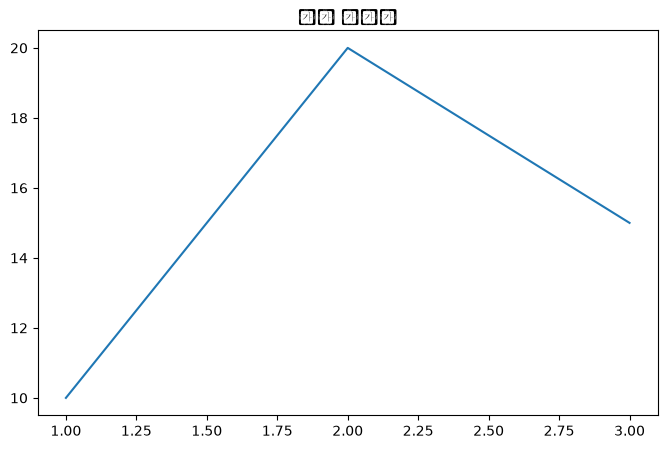

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot([1,2,3],[10,20,15])
plt.title("차트 타이틀")
plt.show()

C:\Users\hiju2\AppData\Local\Temp\ipykernel_24464\2203836838.py:19: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hiju2\AppData\Local\Temp\ipykernel_24464\2203836838.py:19: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hiju2\AppData\Local\Temp\ipykernel_24464\2203836838.py:19: UserWarning: Glyph 52768 (\N{HANGUL SYLLABLE CEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hiju2\AppData\Local\Temp\ipykernel_24464\2203836838.py:19: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hiju2\AppData\Local\Temp\ipykernel_24464\2203836838.py:19: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hiju2\AppData\Local\Temp\ipykernel_24464\2203836838.py:19: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from 

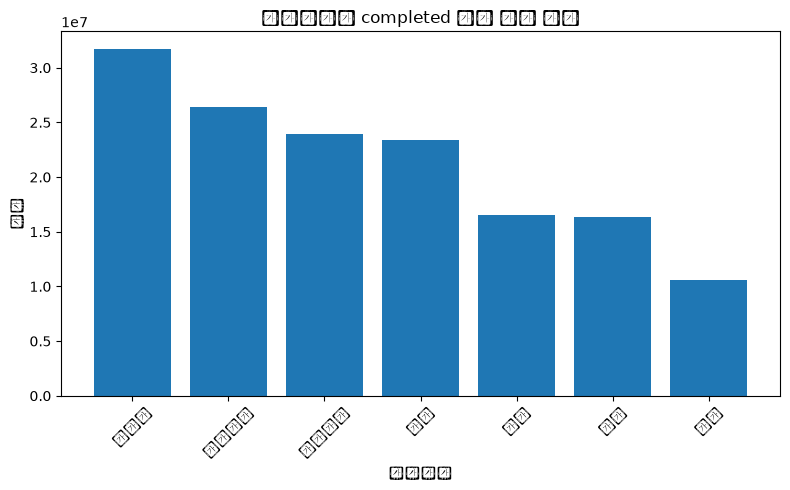

In [20]:

plt.figure(figsize=(8, 5))

plt.bar(

    category_summary["category"],

    category_summary["total_amount"],

)

plt.title("카테고리별 completed 주문 기준 금액")

plt.xlabel("카테고리")

plt.ylabel("금액")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

C:\Users\hiju2\AppData\Local\Temp\ipykernel_24464\3578273677.py:21: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hiju2\AppData\Local\Temp\ipykernel_24464\3578273677.py:21: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hiju2\AppData\Local\Temp\ipykernel_24464\3578273677.py:21: UserWarning: Glyph 52768 (\N{HANGUL SYLLABLE CEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hiju2\AppData\Local\Temp\ipykernel_24464\3578273677.py:21: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hiju2\AppData\Local\Temp\ipykernel_24464\3578273677.py:21: UserWarning: Glyph 54408 (\N{HANGUL SYLLABLE PUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hiju2\AppData\Local\Temp\ipykernel_24464\3578273677.py:21: UserWarning: Glyph 49885 (\N{HANGUL SYLLABLE SIG}) missing fro

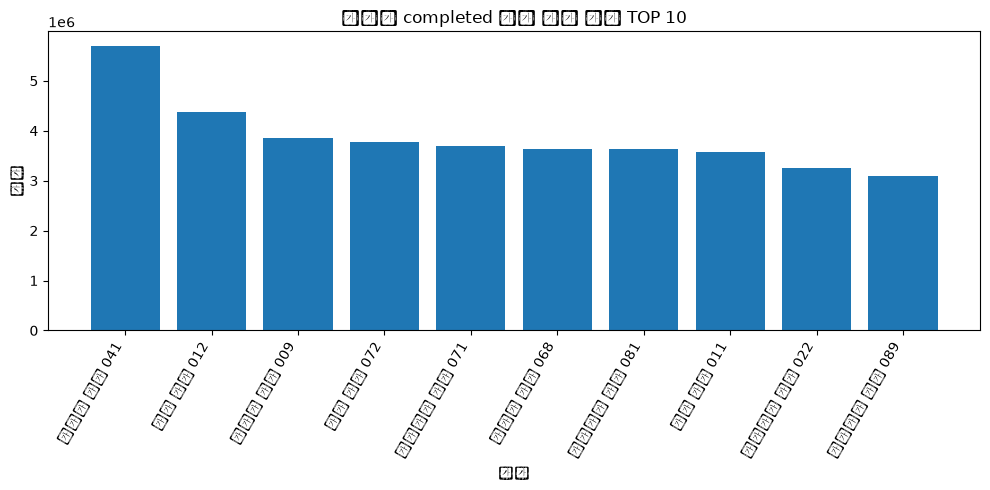

In [21]:
top10_products = product_summary.head(10)

plt.figure(figsize=(10, 5))

plt.bar(

    top10_products["product_name"],

    top10_products["total_amount"],

)

plt.title("제품별 completed 주문 기준 금액 TOP 10")

plt.xlabel("제품")

plt.ylabel("금액")

plt.xticks(rotation=60, ha="right")

plt.tight_layout()

plt.show()

C:\Users\hiju2\AppData\Local\Temp\ipykernel_24464\4137108365.py:21: UserWarning: Glyph 50900 (\N{HANGUL SYLLABLE WEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hiju2\AppData\Local\Temp\ipykernel_24464\4137108365.py:21: UserWarning: Glyph 44552 (\N{HANGUL SYLLABLE GEUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hiju2\AppData\Local\Temp\ipykernel_24464\4137108365.py:21: UserWarning: Glyph 50529 (\N{HANGUL SYLLABLE AEG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hiju2\AppData\Local\Temp\ipykernel_24464\4137108365.py:21: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hiju2\AppData\Local\Temp\ipykernel_24464\4137108365.py:21: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hiju2\AppData\Local\Temp\ipykernel_24464\4137108365.py:21: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing 

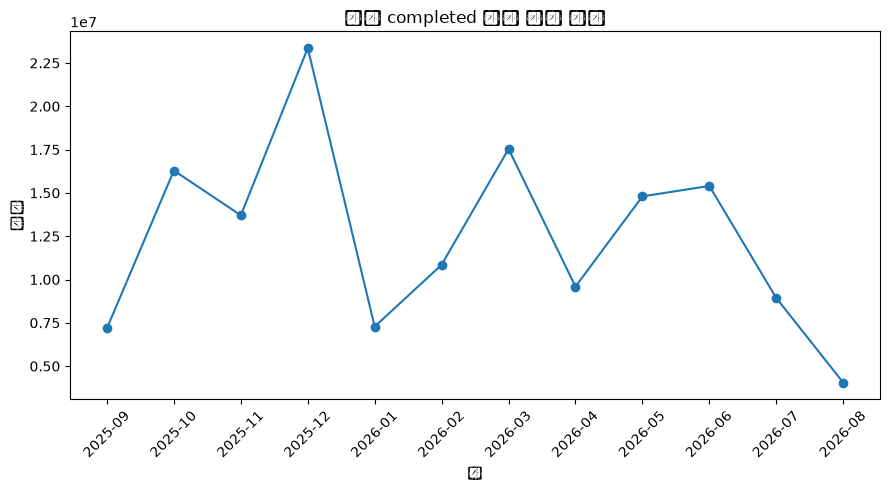

In [22]:

plt.figure(figsize=(9, 5))

plt.plot(

    monthly_summary["order_month"],

    monthly_summary["total_amount"],

    marker="o",

)

plt.title("월별 completed 주문 기준 금액")

plt.xlabel("월")

plt.ylabel("금액")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [28]:
from pathlib import Path
import sys

import pandas as pd

# 프로젝트 폴더 찾기
project_root = next(
    (
        path
        for path in (Path.cwd(), *Path.cwd().parents)
        if (path / "src" / "processing.py").is_file()
        and (path / "data" / "raw").is_dir()
    ),
    None,
)

if project_root is None:
    raise FileNotFoundError(
        "프로젝트 폴더 또는 notebooks 폴더에서 노트북을 실행해 주세요."
    )

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.processing import preprocess_sales_data

# 원본 데이터 불러오기
data_dir = project_root / "data" / "raw"

raw_data = {
    "customers": pd.read_csv(data_dir / "customers.csv"),
    "orders": pd.read_csv(data_dir / "orders.csv"),
    "order_items": pd.read_csv(data_dir / "order_items.csv"),
    "products": pd.read_csv(data_dir / "products.csv"),
}

# 데이터 전처리
processed_data = preprocess_sales_data(raw_data)

# 주문 상세와 주문 정보 결합
order_sales = processed_data["order_items"].merge(
    processed_data["orders"][
        ["order_id", "customer_id", "order_date", "order_status"]
    ],
    on="order_id",
    how="left",
    validate="many_to_one",
)

# 주문 항목별 금액 계산
order_sales["line_total"] = (
    order_sales["quantity"] * order_sales["unit_price"]
)

# 완료된 주문만 선택
completed_sales = order_sales[
    order_sales["order_status"] == "completed"
].copy()

# 고객별 완료 주문금액 계산
customer_order_total = (
    completed_sales
    .groupby("customer_id", as_index=False)
    .agg(order_total=("line_total", "sum"))
)

# 고객 나이 결합
order_summary = (
    processed_data["customers"][["customer_id", "age"]]
    .merge(
        customer_order_total,
        on="customer_id",
        how="left",
        validate="one_to_one",
    )
)

order_summary["order_total"] = order_summary["order_total"].fillna(0)

display(order_summary.head())

,customer_id,age,order_total
0,1,19,0.0
1,2,32,0.0
2,3,61,3178000.0
3,4,55,603000.0
4,5,19,2004000.0


In [29]:
# 주문 상세 + 주문 정보 결합
order_sales = processed_data["order_items"].merge(
    processed_data["orders"][
        ["order_id", "customer_id", "order_date", "order_status"]
    ],
    on="order_id",
    how="left",
    validate="many_to_one",
)

# 주문 항목별 금액 계산
order_sales["line_total"] = (
    order_sales["quantity"] * order_sales["unit_price"]
)

# 완료된 주문만 선택
completed_sales = order_sales[
    order_sales["order_status"] == "completed"
].copy()

# 고객별 완료 주문금액 합계
customer_order_total = (
    completed_sales
    .groupby("customer_id", as_index=False)
    .agg(order_total=("line_total", "sum"))
)

# 고객 나이와 주문금액 결합
order_summary = (
    processed_data["customers"][["customer_id", "age"]]
    .merge(
        customer_order_total,
        on="customer_id",
        how="left",
        validate="one_to_one",
    )
)

# 완료 주문이 없는 고객의 주문금액을 0으로 처리
order_summary["order_total"] = order_summary["order_total"].fillna(0)

display(order_summary.head())

,customer_id,age,order_total
0,1,19,0.0
1,2,32,0.0
2,3,61,3178000.0
3,4,55,603000.0
4,5,19,2004000.0


C:\Users\hiju2\AppData\Local\Temp\ipykernel_24464\3659411083.py:25: UserWarning: Glyph 45208 (\N{HANGUL SYLLABLE NA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hiju2\AppData\Local\Temp\ipykernel_24464\3659411083.py:25: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hiju2\AppData\Local\Temp\ipykernel_24464\3659411083.py:25: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hiju2\AppData\Local\Temp\ipykernel_24464\3659411083.py:25: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hiju2\AppData\Local\Temp\ipykernel_24464\3659411083.py:25: UserWarning: Glyph 44552 (\N{HANGUL SYLLABLE GEUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hiju2\AppData\Local\Temp\ipykernel_24464\3659411083.py:25: UserWarning: Glyph 50529 (\N{HANGUL SYLLABLE AEG}) missing from f

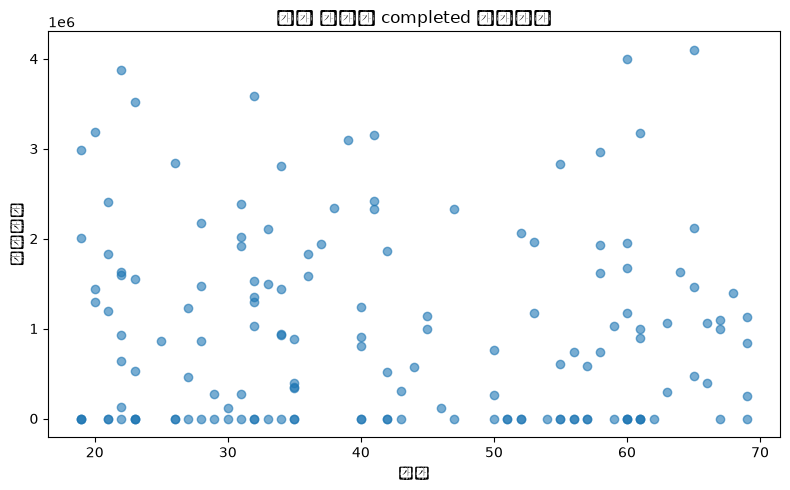

In [30]:
scatter_df = order_summary.dropna(

    subset=["age", "order_total"]

)

plt.figure(figsize=(8, 5))

plt.scatter(

    scatter_df["age"],

    scatter_df["order_total"],

    alpha=0.6,

)

plt.title("고객 나이와 completed 주문금액")

plt.xlabel("나이")

plt.ylabel("주문금액")

plt.tight_layout()

plt.show()


In [31]:
plt.figure(figsize=(6, 6))

plt.pie(

    payment_summary["order_count"],

    labels=payment_summary["payment_method"],

    autopct="%1.1f%%",

)

plt.title("completed 주문의 결제수단 구성")

plt.tight_layout()

plt.show()

NameError: name 'payment_summary' is not defined

<Figure size 600x600 with 0 Axes>